In [1]:
#importing libraries 
from dolfinx.io import XDMFFile
from dolfinx.mesh import meshtags_from_entities
from dolfinx.cpp.mesh import cell_entity_type
from dolfinx.io import distribute_entity_data
from dolfinx.graph import adjacencylist
from dolfinx.mesh import create_mesh
from dolfinx.cpp.mesh import to_type
from dolfinx.cpp.io import perm_gmsh
import numpy
from mpi4py import MPI
import dolfinx.io 
import numpy as np
import gmsh
import warnings
from dolfinx.io import VTXWriter, gmshio as gmshio
from basix.ufl import element
from dolfinx.fem import (
    Constant,
    Function,
    functionspace,
    assemble_scalar,
    dirichletbc,
    extract_function_spaces,
    form,
    locate_dofs_topological,
    set_bc,
    Expression,
)
from petsc4py import PETSc
import ufl
from dolfinx.fem.petsc import (
    apply_lifting,
    assemble_matrix,
    assemble_vector,
    create_vector,
    create_matrix,
    set_bc,
)
from ufl import (
    FacetNormal,
    Measure,
    TestFunction,
    TrialFunction,
    as_vector,
    div,
    dot,
    dx,
    inner,
    lhs,
    grad,
    nabla_grad,
    rhs,
)
from dolfinx.geometry import bb_tree, compute_collisions_points, compute_colliding_cells
import tqdm.autonotebook
from ufl import exp, sym, min_value, max_value, sqrt
import numpy as np
import dolfinx.geometry
from dolfinx.mesh import locate_entities_boundary

In [2]:
#Fluid Domain
import gmsh
gmsh.initialize()
gmsh.model.add("box_with_positioned_object")

# Create box with padding
box_padding = 1.0  # Space between object and box walls
box_width = 10.0
box_height = 5.0
box_depth = 3.0
box = gmsh.model.occ.addBox(0, 0, 0, box_width, box_height, box_depth)
#box = gmsh.model.occ.addCylinder(0,0,0,box_width,box_height,box_depth,1.5)
# Import STEP file
imported = gmsh.model.occ.importShapes("Gmsh_foil2.step")

# Recalculate dimensions after scaling
xmin, ymin, zmin, xmax, ymax, zmax = gmsh.model.occ.getBoundingBox(
    imported[0][0], imported[0][1]
)
print(xmin, ymin, zmin, xmax, ymax, zmax)
obj_width = xmax - xmin
obj_height = ymax - ymin
obj_depth = zmax - zmin

# Position at center of box
center_x = (box_width - obj_width) / 2
center_y = (box_height - obj_height) / 2
center_z = (box_depth - obj_depth) / 2

# Translate to desired position
gmsh.model.occ.translate(imported, center_x, center_y, center_z)

# Create assembly (group objects together)
fluid_domain = gmsh.model.occ.cut([(3, box)], imported)
gmsh.model.occ.synchronize()

# Get all volumes (should be just fluid domain after cut)
all_volumes = gmsh.model.getEntities(3)
fluid_volume_tag = all_volumes[0][1]

# Create physical group for FLUID DOMAIN
gmsh.model.addPhysicalGroup(3, [fluid_volume_tag], 100)
gmsh.model.setPhysicalName(3, 100, "FluidDomain")


all_surfaces = gmsh.model.getEntities(2)
print(all_surfaces)

# Identify boundaries by position for CFD
inlet_surfaces = []
outlet_surfaces = []
walls_surfaces = []
object_surfaces = []
upper_wall_surfaces = []

for dim, tag in all_surfaces:
    # Get surface center
    com = gmsh.model.occ.getCenterOfMass(dim, tag)
    x, y, z = com
    # Classify boundaries
    if abs(x - 0) < 0.1:  # x=0 face
        print("inlet", tag)
        inlet_surfaces.append(tag)
    elif abs(x - 10) < 0.1:  # x=20 face
        print("outlet", tag)
        outlet_surfaces.append(tag)  
    elif abs(y - 0) < 0.1  or abs(z - 0) < 0.1 or abs(z - 3) < 0.1:
        print("walls", tag)
        walls_surfaces.append(tag)  # box walls
    elif abs(y - 5) < 0.1 or abs(z - 0) < 0.1 or abs(z - 3) < 0.1:
        print("upper", tag)
        upper_wall_surfaces.append(tag)     
    else:
        print("obs", tag)
        object_surfaces.append(tag)  # object surface
# Create physical groups for boundaries
if inlet_surfaces:
    gmsh.model.addPhysicalGroup(2, inlet_surfaces, 200)
    gmsh.model.setPhysicalName(2, 200, "Inlet")

if outlet_surfaces:
    gmsh.model.addPhysicalGroup(2, outlet_surfaces, 201)
    gmsh.model.setPhysicalName(2, 201, "Outlet")

if walls_surfaces:
    gmsh.model.addPhysicalGroup(2, walls_surfaces, 202)
    gmsh.model.setPhysicalName(2, 202, "Walls")
if upper_wall_surfaces:
    gmsh.model.addPhysicalGroup(2, upper_wall_surfaces, 204)
    gmsh.model.setPhysicalName(2, 204, "upper_wall_surfaces")

if object_surfaces:
    gmsh.model.addPhysicalGroup(2, object_surfaces, 203)
    gmsh.model.setPhysicalName(2, 203, "Obstacle")
print("="*50)
print("Boundary conditions defined:")
print(f"  Inlet:    {len(inlet_surfaces)} surfaces")
print(f"  Outlet:   {len(outlet_surfaces)} surfaces")
print(f"  Walls:    {len(walls_surfaces)} surfaces")
print(f"  Obstacle: {len(object_surfaces)} surfaces")
print(f"  upper_wall_surfaces: {len(upper_wall_surfaces)} surfaces")
print("="*50)
r=1
distance = gmsh.model.mesh.field.add("Distance")
gmsh.model.mesh.field.setNumbers(distance, "FacesList", object_surfaces)
resolution = r / 10
threshold = gmsh.model.mesh.field.add("Threshold")
gmsh.model.mesh.field.setNumber(threshold, "IField", distance)
gmsh.model.mesh.field.setNumber(threshold, "LcMin", resolution)
gmsh.model.mesh.field.setNumber(threshold, "LcMax", 1.0)
gmsh.model.mesh.field.setNumber(threshold, "DistMin", 0.1)
gmsh.model.mesh.field.setNumber(threshold, "DistMax", 0.5)
inlet_dist = gmsh.model.mesh.field.add("Distance")
gmsh.model.mesh.field.setNumbers(inlet_dist, "FacesList", [inlet_surfaces[0]])
inlet_thre = gmsh.model.mesh.field.add("Threshold")
gmsh.model.mesh.field.setNumber(inlet_thre, "IField", inlet_dist)
gmsh.model.mesh.field.setNumber(inlet_thre, "LcMin", 5 * resolution)
gmsh.model.mesh.field.setNumber(inlet_thre, "LcMax", 10 * resolution)
gmsh.model.mesh.field.setNumber(inlet_thre, "DistMin", 0.1)
gmsh.model.mesh.field.setNumber(inlet_thre, "DistMax", 0.5)
minimum = gmsh.model.mesh.field.add("Min")
gmsh.model.mesh.field.setNumbers(minimum, "FieldsList", [threshold, inlet_thre])
gmsh.model.mesh.field.setAsBackgroundMesh(minimum)
gmsh.model.occ.synchronize()
gmsh.model.mesh.generate(3)
# Optional: Refine mesh (improve quality)
gmsh.model.mesh.refine()
print("Mesh refined")


# # 1. Combine all surfaces where you want refinement
# # This includes walls, the obstacle, and optionally inlet/outlet
# refinement_surfaces = walls_surfaces + object_surfaces + inlet_surfaces + outlet_surfaces

# r = 1
# resolution = r / 10  # Fine element size near walls

# # 2. Setup Distance Field
# # This calculates the distance from any point in the volume to the nearest surface in the list
# dist_field = gmsh.model.mesh.field.add("Distance")
# gmsh.model.mesh.field.setNumbers(dist_field, "FacesList", refinement_surfaces)

# # 3. Setup Threshold Field
# # This defines how the mesh size (Lc) changes based on the distance calculated above
# threshold_field = gmsh.model.mesh.field.add("Threshold")
# gmsh.model.mesh.field.setNumber(threshold_field, "IField", dist_field)
# gmsh.model.mesh.field.setNumber(threshold_field, "LcMin", resolution)      # Size at the wall
# gmsh.model.mesh.field.setNumber(threshold_field, "LcMax", 1.0)             # Size far from the wall
# gmsh.model.mesh.field.setNumber(threshold_field, "DistMin", 0.1)           # Distance where LcMin applies
# gmsh.model.mesh.field.setNumber(threshold_field, "DistMax", 0.5)           # Distance where Lc transitions to LcMax

# # 4. Set as Background Mesh
# gmsh.model.mesh.field.setAsBackgroundMesh(threshold_field)

# # Finalize and Generate
# gmsh.model.occ.synchronize()
# gmsh.model.mesh.generate(3)

# Optional: Refine mesh (subdivides elements)
# gmsh.model.mesh.refine()


Info    :  - Label 'Shapes/Open CASCADE STEP translator 7.8 2/3/Open CASCADE STEP translator 7.8 2.1' (3D)
Info    :  - Label 'Shapes/Open CASCADE STEP translator 7.8 2/4/Open CASCADE STEP translator 7.8 2.2' (3D)
-1e-07 -0.06001895423294 -1e-07 1.0000001 0.06001895423294 0.3000001
[(2, 7), (2, 8), (2, 9), (2, 10), (2, 11), (2, 12), (2, 13), (2, 14), (2, 15), (2, 16)]                                                        
obs 7
obs 8
obs 9
obs 10
inlet 11
walls 12
walls 13
upper 14
walls 15
outlet 16
Boundary conditions defined:
  Inlet:    1 surfaces
  Outlet:   1 surfaces
  Walls:    3 surfaces
  Obstacle: 4 surfaces
  upper_wall_surfaces: 1 surfaces
Info    : Meshing 1D...
Info    : [  0%] Meshing curve 13 (Line)
Info    : [ 10%] Meshing curve 14 (BSpline)
Info    : [ 20%] Meshing curve 15 (Line)
Info    : [ 20%] Meshing curve 16 (BSpline)
Info    : [ 30%] Meshing curve 17 (BSpline)
Info    : [ 30%] Meshing curve 18 (BSpline)
Info    : [ 40%] Meshing curve 19 (Line)
Info    : [ 40%

In [ ]:
#uncomment to view the meshing
#gmsh.fltk.run()

-------------------------------------------------------
Version       : 4.15.0
License       : GNU General Public License
Build OS      : Linux64-sdk
Build date    : 20251121
Build host    : 4ce478da1c1b
Build options : 64Bit ALGLIB[contrib] ANN[contrib] Bamg Blossom Cairo DIntegration Dlopen DomHex Eigen[contrib] Fltk GMP Gmm[contrib] Hxt Jpeg Kbipack LinuxJoystick MathEx[contrib] Mesh Metis[contrib] Mpeg Netgen Nii2mesh ONELAB ONELABMetamodel OpenCASCADE OpenCASCADE-CAF OpenGL OpenMP OptHom Parser Plugins Png Post QuadMeshingTools QuadTri Solver TetGen/BR TinyXML2[contrib] Untangle Voro++[contrib] WinslowUntangler Zlib tinyobjloader
FLTK version  : 1.3.10
OCC version   : 7.9.1
Packaged by   : conda
Web site      : https://gmsh.info
Issue tracker : https://gitlab.onelab.info/gmsh/gmsh/issues
-------------------------------------------------------


In [4]:
#importing the geometry into dolfinx
model_rank = 0
mesh, cell_tags, facet_tags = gmshio.model_to_mesh(gmsh.model, MPI.COMM_WORLD, model_rank)
t = 0.0
T = 5.0  # Final time
dt = 1 / 10  # Time step size
num_steps = int(T / dt)

In [5]:
#Defining the boundary conditions slanted flow
v_cg2 = element("Lagrange", mesh.basix_cell(), 2, shape=(mesh.geometry.dim,))    #used to define the velocity as vector field so that it can have x,y,z compenent
s_cg1 = element("Lagrange", mesh.basix_cell(), 1)   #same goes for pressure because we need velocity and pressure for all points in the mesh
V = functionspace(mesh, v_cg2)      #Creates the global numbering of degrees of freedom for velocity
Q = functionspace(mesh, s_cg1)      #Creates the global numbering for pressure degrees of freedom
K = functionspace(mesh, s_cg1)
    
fdim = mesh.topology.dim - 1 

class InletVelocity:
    def __init__(self, t, Umax):
        self.t = t
        self.Umax = Umax
        self.y_min, self.y_max = 0.0, 5.0

    def __call__(self, x):
        values = np.zeros((3, x.shape[1]), dtype=PETSc.ScalarType)

        y = x[1]
        H = self.y_max - self.y_min

        # normalized height in [0,1]
        eta = (y - self.y_min) / H
        eta = np.clip(eta, 0.0, 1.0)

        # smooth monotone profile: u=0 at bottom, u=Umax at top
        values[0] = self.Umax 
        #* eta

        return values
# Inlet
u_inlet = Function(V)
inlet_velocity = InletVelocity(t,0.5)                         #i can define the velocity wtr to time if i want just use the code in ns2
u_inlet.interpolate(inlet_velocity)
bcu_inflow = dirichletbc(
    u_inlet, locate_dofs_topological(V, fdim, facet_tags.find(200))             #we are finding the inlet facet tags to know which part is the inlet using facet_tags.find, then finding the inlet degree of freedom
)
# Walls
u_nonslip = np.array((0,) * mesh.geometry.dim, dtype=PETSc.ScalarType)                   #creating a vector of zeros whose lengtj-h is equal to the spatial dimentions 3D that is obtained by the  mesh.geometry.dim since we are using non slip condition
bcu_walls = dirichletbc(
    u_nonslip, locate_dofs_topological(V, fdim, facet_tags.find(202)), V         # V here specifes the function spave to which the boundary condtion applies
)
bc_free = dirichletbc(
    u_nonslip, locate_dofs_topological(V, fdim, facet_tags.find(204)), V         # V here specifes the function spave to which the boundary condtion applies
)
y_top = 5.0
tol = 1e-8

def upper_wall(x):
    return np.isclose(x[1], y_top, atol=tol)

facets_top = locate_entities_boundary(mesh, fdim, upper_wall)

# Enforce uy = 0 on y=5
dofs_uy_top = locate_dofs_topological(V.sub(1), fdim, facets_top)
bc_free = dirichletbc(PETSc.ScalarType(0), dofs_uy_top, V.sub(1))

# Obstacle
bcu_obstacle = dirichletbc(
    u_nonslip, locate_dofs_topological(V, fdim, facet_tags.find(203)), V     #same no slip condition applied to obstacle
)
bcu = [bcu_inflow, bcu_obstacle, bcu_walls,bc_free]
# Outlet
bcp_outlet = dirichletbc(
    PETSc.ScalarType(0), locate_dofs_topological(Q, fdim, facet_tags.find(201)), Q
)
bcp = [bcp_outlet]
#############################################################################################################
u_max = 0.5
K_in = 2/3*(u_max*0.05)**2
E_in= ((0.09)**(3/4))* (K_in)**(3/2) / 10
bck_inlet = dirichletbc(
    PETSc.ScalarType(K_in), locate_dofs_topological(K, fdim, facet_tags.find(202)), K       
)
bck_wall = dirichletbc(
    PETSc.ScalarType(0), locate_dofs_topological(K, fdim, facet_tags.find(202)), K       
)
bck_Uwall = dirichletbc(
    PETSc.ScalarType(0), locate_dofs_topological(K, fdim, facet_tags.find(204)), K       
)
bck_obstacle = dirichletbc(
    PETSc.ScalarType(0), locate_dofs_topological(K, fdim, facet_tags.find(203)), K       
)
bce_inlet = dirichletbc(
    PETSc.ScalarType(E_in), locate_dofs_topological(K, fdim, facet_tags.find(202)), K       
)
bce_wall = dirichletbc(
    PETSc.ScalarType(0), locate_dofs_topological(K, fdim, facet_tags.find(202)), K       
)
bce_Uwall = dirichletbc(
    PETSc.ScalarType(0), locate_dofs_topological(K, fdim, facet_tags.find(204)), K       
)
bce_obstacle = dirichletbc(
    PETSc.ScalarType(0), locate_dofs_topological(K, fdim, facet_tags.find(203)), K       
)
bck=[bck_inlet,bck_wall,bck_Uwall,bck_obstacle]
bce = [bce_inlet,bce_wall,bce_Uwall,bce_obstacle]


In [6]:
#velocity test and trial functions
u = TrialFunction(V)                             
v = TestFunction(V)
#pressure test and trial fubnctions
p = TrialFunction(Q)
q = TestFunction(Q)
#---------------------------------------------------------------------------------------
#velocity variables
u_ = Function(V, name="u")
u_s = Function(V, name="u_tentative")
u_n = Function(V)
u_n1 = Function(V)
#pressure variables 
p_ = Function(Q, name="p")
p_n = Function(Q, name="p_current")
phi = Function(Q, name="phi")
#constants
k = Constant(mesh, PETSc.ScalarType(dt))
mu = Constant(mesh, PETSc.ScalarType(0.001))  # Dynamic viscosity
rho = Constant(mesh, PETSc.ScalarType(1))  # Density
f = Constant(mesh, PETSc.ScalarType((0, 0, 0)))
#variables
mu_t = Function(Q, name="turbulent_viscosity")


In [7]:
simulation_prm = {
    'QUADRATURE_DEGREE': 2,
    'MAX_ITERATIONS': 3000,
    'TOLERANCE': 1e-6,
    'CFL_RELAXATION': 0.25
}
quadrature_degree = simulation_prm['QUADRATURE_DEGREE']
dx = Measure("dx", domain=mesh, metadata={"quadrature_degree": quadrature_degree})
ds = Measure("ds", domain=mesh, metadata={"quadrature_degree": quadrature_degree})
def bound_from_bellow(f, lb):
    '''bounds function f from below by lb'''
    # Create a new function in the same space as f
    new_f = Function(f.function_space) 
    
    # Access the underlying array directly
    # f.x.array provides the local values of the vector
    data = f.x.array
    
    # Apply the lower bound using numpy
    new_f.x.array[:] = np.maximum(data, lb)
    
    # Update the ghost values (crucial for parallel runs)
    new_f.x.scatter_forward()
    
    return new_f

In [8]:
# Turbulent Model
class KEpsilonGeneral:
    def __init__(self, K, bck, bce, k_init, e_init, nu, force, custom_dx, custom_ds, distance_field,rho):
        # K-epsilon model parameters
        self._K = K
        self._bck = bck
        self._bce = bce
        self._k_init = k_init
        self._e_init = e_init

        # General parameters
        self.mu = nu
        self._force = force
        self._dx = custom_dx
        self._ds = custom_ds
        self._y = distance_field  # distance function
        self.rho =rho

        # Initialize all functions
        self._construct_functions()
    def _construct_functions(self):
        self.k_trial = TrialFunction(K)
        self.k_test = TestFunction(K)
        self.k_current = Function(K, name="k_current") 
        self.k_previous = Function(K, name="k_previous") 
        self.epsilon_trial = TrialFunction(K)
        self.epsilon_test = TestFunction(K)
        self.epsilon_current = Function(K, name="epsilon_current")
        self.epsilon_previous = Function(K, name="epsilon_previous") 
    def construct_forms(self):
        raise NotImplementedError("This method must be implemented in subclasses.")
    def solve_turbulence_model(self):
        A4 = create_matrix(self.a4)
        b4 = create_vector((self.L4))
        # Solver for step 4
        solver4 = PETSc.KSP().create(mesh.comm)
        solver4.setOperators(A4)
        solver4.setType(PETSc.KSP.Type.BCGS)
        pc1 = solver4.getPC()
        pc1.setType(PETSc.PC.Type.JACOBI)
        # 4a. Solve for k
        A4.zeroEntries()
        assemble_matrix(A4, self.a4, bcs=self._bck) # ak is the bilinear form for k
        A4.assemble()
        with b4.localForm() as loc:
            loc.set(0)
        assemble_vector(b4, self.L4)          # Lk is the linear form for k
        apply_lifting(b4, [self.a4], [self._bck])
        b4.ghostUpdate(addv=PETSc.InsertMode.ADD_VALUES, mode=PETSc.ScatterMode.REVERSE)
        set_bc(b4, self._bck)
        solver4.solve(b4, self.k_current.x.petsc_vec)
        # 1. Create a vector of the same size as k_
        floor_vec = self.k_current.x.petsc_vec.duplicate()
        # 2. Fill it with the floor value
        floor_vec.set(1e-12)
        # 3. Perform the comparison (k_ = max(k_, floor_vec))
        self.k_current.x.petsc_vec.pointwiseMax(self.k_current.x.petsc_vec, floor_vec)
        self.k_current.x.scatter_forward()

        A5 = create_matrix(self.a5)
        b5 = create_vector((self.L5))
        solver5 = PETSc.KSP().create(mesh.comm)
        solver5.setOperators(A5)
        solver5.setType(PETSc.KSP.Type.BCGS)
        pc1 = solver5.getPC()
        pc1.setType(PETSc.PC.Type.JACOBI)
        A5.zeroEntries()
        assemble_matrix(A5, self.a5, bcs=self._bce) # aw is the bilinear form for omega
        A5.assemble()
        with b5.localForm() as loc:
            loc.set(0)
        assemble_vector(b5, self.L5)
        apply_lifting(b5, [self.a5], [self._bce])
        b5.ghostUpdate(addv=PETSc.InsertMode.ADD_VALUES, mode=PETSc.ScatterMode.REVERSE)
        set_bc(b5, self._bce)
        solver5.solve(b5, self.epsilon_current.x.petsc_vec)
        floor_vec1 = self.epsilon_current.x.petsc_vec.duplicate()
        floor_vec1.set(1e-12)
        self.epsilon_current.x.petsc_vec.pointwiseMax(self.epsilon_current.x.petsc_vec, floor_vec1)
        self.epsilon_current.x.scatter_forward()
        # bound from bellow
        self._k1 = bound_from_bellow(self.k_current, 1e-16)
        self._e1 = bound_from_bellow(self.epsilon_current, 1e-16)
    def update_variables(self, relaxation=1.0):
        """Update k and e variables with relaxation."""
        # Update k: k_prev = rel * k_curr + (1 - rel) * k_prev
        self.k_previous.x.array[:] = (relaxation * self.k_current.x.array + 
                                    (1.0 - relaxation) * self.k_previous.x.array)
        
        # Update epsilon: e_prev = rel * e_curr + (1 - rel) * e_prev
        self.epsilon_previous.x.array[:] = (relaxation * self.epsilon_current.x.array + 
                                            (1.0 - relaxation) * self.epsilon_previous.x.array)
        
        # Crucial: Sync ghost values if running in parallel
        self.k_previous.x.scatter_forward()
        self.epsilon_previous.x.scatter_forward()

    def _construct_turbulent_quantities(self, u_n):
        Re_t = (1. / self.mu) * (self.k_previous**2 / self.epsilon_previous) 
        Re_k = (1. / self.mu) * (sqrt(self.k_previous) * self._y) 

        f_nu = max_value(min_value((1 - exp(- 0.0165 * Re_k))**2 * (1 + 20.5 / Re_t), Constant(mesh,1.0)), Constant(mesh,0.01116225))
        f_1  = 1 + (0.05 / f_nu)**3
        f_2  = max_value(min_value(1 - exp(- Re_t**2), Constant(mesh, 1.0)), Constant(mesh,0.0))
        S_sq = 2 * inner(sym(nabla_grad(u_n)), sym(nabla_grad(u_n)))

        # Define turbulent quantities
        self._mu_t_expr = 0.09 * f_nu * (self.k_previous**2 / self.epsilon_previous)
        self.Prod_k = self._mu_t_expr * S_sq
        self.react_k = self.epsilon_previous / self.k_previous
        self.prod_e = 1.44 * self.react_k * f_1 * self.Prod_k
        self.react_e = 1.92 * self.react_k * f_2

    # Properties which are refered to in main
    @property
    def mu_t_expr(self):
        return self._mu_t_expr

    @property
    def k0(self):
        return self.k_previous

    @property
    def k1(self):
        return self.k_current

    @property
    def e0(self):
        return self.epsilon_previous

    @property
    def e1(self):
        return self._e1
    
class KEpsilonSteadyState(KEpsilonGeneral):
    def __init__(self, K, bck, bce, k_init, e_init, nu, force, custom_dx, custom_ds, distance_field,rho):
        super().__init__(K, bck, bce, k_init, e_init, nu, force, custom_dx, custom_ds, distance_field,rho)   
                
    def construct_forms(self, u_n):
        self._construct_turbulent_quantities(u_n)
        FK = dot(dot(u_n, nabla_grad(self.k_trial)), self.k_test)*dx \
        +inner((self.mu + self._mu_t_expr) * grad(self.k_trial), grad(self.k_test)) * dx \
        -dot(self.Prod_k , self.k_test) * dx \
        + dot(self.react_k * self.k_trial , self.k_test) * dx
        self.a4 = form(lhs(FK))
        self.L4 = form(rhs(FK))
        FE =dot(dot(u_n, nabla_grad(self.epsilon_trial)), self.epsilon_test)*dx \
        +inner(((self.mu + self._mu_t_expr)/1.3) * grad(self.epsilon_trial), grad(self.epsilon_test)) * dx \
        -dot(self.prod_e , self.epsilon_test) * dx \
        + dot(self.react_e * self.epsilon_trial , self.epsilon_test) * dx
        self.a5 = form(lhs(FE))
        self.L5 = form(rhs(FE))
        
class KEpsilonTransient(KEpsilonGeneral):
    def __init__(self, K, bck, bce, k_init, e_init, nu, force, custom_dx, custom_ds, dt, distance_field,rho):
        self._dt = dt
        super().__init__(K, bck, bce, k_init, e_init, nu, force, custom_dx, custom_ds, distance_field,rho)       
        
    def construct_forms(self, u_n):
        self._construct_turbulent_quantities(u_n)
        FK = self.rho / self._dt* dot((self.k_trial-self.k_previous) , self.k_test)*dx \
        + dot(dot(u_n, nabla_grad(self.k_trial)), self.k_test)*dx \
        +inner((self.mu + self._mu_t_expr) * grad(self.k_trial), grad(self.k_test)) * dx \
        -dot(self.Prod_k , self.k_test) * dx \
        + dot(self.react_k * self.k_trial , self.k_test) * dx
        self.a4 = form(lhs(FK))
        self.L4 = form(rhs(FK))


        FE = self.rho / self._dt * dot((self.epsilon_trial-self.epsilon_previous) , self.epsilon_test)*dx \
        + dot(dot(u_n, nabla_grad(self.epsilon_trial)), self.epsilon_test)*dx \
        +inner(((self.mu + self._mu_t_expr)/1.3) * grad(self.epsilon_trial), grad(self.epsilon_test)) * dx \
        -dot(self.prod_e , self.epsilon_test) * dx \
        + dot(self.react_e * self.epsilon_trial , self.epsilon_test) * dx
        self.a5 = form(lhs(FE))
        self.L5 = form(rhs(FE))

In [9]:
#main model
#Wall Distance Calculation (Critical for k-epsilon)
wall_facets = facet_tags.find(202)
obstacle_facets = facet_tags.find(203)
all_wall_facets = np.concatenate((wall_facets, obstacle_facets))
gdim = mesh.topology.dim
tree = dolfinx.geometry.bb_tree(mesh, gdim - 1, all_wall_facets)
midpoints = Q.tabulate_dof_coordinates()
closest_entities = dolfinx.geometry.compute_closest_entity(tree, tree, mesh, midpoints)
squared_distances = dolfinx.geometry.squared_distance(mesh, gdim - 1, closest_entities, midpoints)
d = Function(Q)
d.x.array[:] = np.sqrt(squared_distances)
d.x.array[d.x.array < 1e-6] = 1e-6 # Avoid division by zero

initial_conditions = {
    'K': 0.0937,
    'E': 0.0225
}
# Initialize turbulence model
turbulence_model = KEpsilonTransient(K, bck, bce, initial_conditions['K'] , initial_conditions['E'],
                            mu, f, dx, ds, k, d,rho)
turbulence_model.construct_forms(u_n)


In [10]:
u_mid = 0.5 * (u + u_n)
def S(w):
    return sym(nabla_grad(w))
#turb_iso = (2.0/3.0) * rho * self.k_current * div(v) * dx
#writing the Problem u_
#-----------STEP 1 --------------------
# Updated Variational form for the first step
F1 = rho / k * dot(u - u_n, v) * dx
F1 += inner(dot(1.5 * u_n - 0.5 * u_n1, 0.5 * nabla_grad(u_mid)), v) * dx
# Use mu_eff instead of mu for the diffusion term
F1 += 2.0 * (mu + turbulence_model.mu_t_expr) * inner(S(u_mid), S(v)) * dx - dot(p_, div(v)) * dx
#F1 += turb_iso
F1 += dot(f, v) * dx
a1 = form(lhs(F1))
L1 = form(rhs(F1))
A1 = create_matrix(a1)
b1 = create_vector((L1))

#-----------------------STEP 2-------------------------
a2 = form(dot(grad(p), grad(q)) * dx)
L2 = form(-rho / k * dot(div(u_s), q) * dx)
A2 = assemble_matrix(a2, bcs=bcp)
A2.assemble()
# b2 = create_vector(extract_function_spaces(L2))
b2 = create_vector((L2))

#--------------------STEP 3-----------------------------
a3 = form(rho * dot(u, v) * dx)
L3 = form(rho * dot(u_s, v) * dx - k * dot(nabla_grad(phi), v) * dx)
A3 = assemble_matrix(a3)
A3.assemble()
# b3 = create_vector(extract_function_spaces(L3))
b3 = create_vector((L3))

In [11]:
#writing the SOLVERS
# Solver for step 1
solver1 = PETSc.KSP().create(mesh.comm)
solver1.setOperators(A1)
solver1.setType(PETSc.KSP.Type.BCGS)
pc1 = solver1.getPC()
pc1.setType(PETSc.PC.Type.JACOBI)

# Solver for step 2
solver2 = PETSc.KSP().create(mesh.comm)
solver2.setOperators(A2)
solver2.setType(PETSc.KSP.Type.MINRES)
pc2 = solver2.getPC()
pc2.setType(PETSc.PC.Type.HYPRE)
pc2.setHYPREType("boomeramg")

# Solver for step 3
solver3 = PETSc.KSP().create(mesh.comm)
solver3.setOperators(A3)
solver3.setType(PETSc.KSP.Type.CG)
pc3 = solver3.getPC()
pc3.setType(PETSc.PC.Type.SOR)

# # Solver for step 4
# solver4 = PETSc.KSP().create(mesh.comm)
# solver4.setOperators(A4)
# solver4.setType(PETSc.KSP.Type.BCGS)
# pc1 = solver4.getPC()
# pc1.setType(PETSc.PC.Type.JACOBI)

# # Solver for step 4
# solver5 = PETSc.KSP().create(mesh.comm)
# solver5.setOperators(A5)
# solver5.setType(PETSc.KSP.Type.BCGS)
# pc1 = solver5.getPC()
# pc1.setType(PETSc.PC.Type.JACOBI)

In [12]:
# In 3D, ensure n points OUT of the fluid and INTO the obstacle for standard sign convention
n = -FacetNormal(mesh) 
dObs = Measure("ds", domain=mesh, subdomain_data=facet_tags, subdomain_id=203)

# --- 2. Fluid Stress Tensor (Turbulent) ---
# sigma = -p*I + (mu + mu_t)*(grad(u) + grad(u).T)
# This accounts for both pressure and skin friction in 3D
epsilon = lambda u: 0.5 * (ufl.grad(u) + ufl.grad(u).T)
sigma = -p_ * ufl.Identity(len(u_)) + 2.0 * (mu) * epsilon(u_)

# --- 3. Directional Vectors ---
# Drag is usually along the X-axis, Lift along the Z-axis (3D height)
# Adjust these based on your specific flow orientation
drag_direction = Constant(mesh, np.array([1.0, 0.0, 0.0], dtype=np.float64))
lift_direction = Constant(mesh, np.array([0.0, 0.0, 1.0], dtype=np.float64))

# --- 4. Projected Reference Area (A_ref) ---
# Automatically calculate planform area (shadow on XY plane)
# This replaces the static '0.1' divisor from your 2D code
A_ref = mesh.comm.allreduce(
assemble_scalar(form(1.0 * dObs)),
op=MPI.SUM
)
if mesh.comm.rank == 0:
    print("Wing surface area =", A_ref)

# --- 5. Force Forms ---
# We integrate the traction vector (sigma * n) dotted with the direction
drag_force_form = form(ufl.dot(ufl.dot(sigma, n), drag_direction) * dObs)
lift_force_form = form(ufl.dot(ufl.dot(sigma, n), lift_direction) * dObs)

# --- 6. Initialization (Rank 0) ---
if mesh.comm.rank == 0:
    print(f"Calculated 3D Reference Area: {A_ref:.6f}")
    C_D = np.zeros(num_steps, dtype=PETSc.ScalarType)
    C_L = np.zeros(num_steps, dtype=PETSc.ScalarType)
    t_u = np.zeros(num_steps, dtype=np.float64)
    t_p = np.zeros(num_steps, dtype=np.float64)

#Below we did something to find the pressure difference
tree = bb_tree(mesh, mesh.geometry.dim)
# points = np.array([[0.5, 0, 0.2], [0, 0.41, 0]])
points = np.array([[0 ,-0.06001895423294, 0], [1.0000001, 0.06001895423294, 0.3000001]])
cell_candidates = compute_collisions_points(tree, points)
colliding_cells = compute_colliding_cells(mesh, cell_candidates, points)
front_cells = colliding_cells.links(0)
back_cells = colliding_cells.links(1)
if mesh.comm.rank == 0:
    p_diff = np.zeros(num_steps, dtype=PETSc.ScalarType)

Wing surface area = 0.7730185214364261
Calculated 3D Reference Area: 0.773019


In [13]:
from dolfinx.io import VTKFile
from pathlib import Path
folder = Path("results")
folder.mkdir(exist_ok=True, parents=True)
vtk_u = VTKFile(mesh.comm, str(folder / "velocity.pvd"), "w")  # open once
progress = tqdm.autonotebook.tqdm(desc="Solving PDE", total=num_steps)
for i in range(num_steps):
    progress.update(1)
    # Update current time step
    t += dt
    
    inlet_velocity.t = t
    u_inlet.interpolate(inlet_velocity)

    # Step 1: Tentative velocity step
    A1.zeroEntries()
    assemble_matrix(A1, a1, bcs=bcu)
    A1.assemble()
    with b1.localForm() as loc:
        loc.set(0)
    assemble_vector(b1, L1)
    apply_lifting(b1, [a1], [bcu])
    b1.ghostUpdate(addv=PETSc.InsertMode.ADD_VALUES, mode=PETSc.ScatterMode.REVERSE)
    set_bc(b1, bcu)
    solver1.solve(b1, u_s.x.petsc_vec)
    u_s.x.scatter_forward()
    # Step 2: Pressure corrrection step
    with b2.localForm() as loc:
        loc.set(0)
    assemble_vector(b2, L2)
    apply_lifting(b2, [a2], [bcp])
    b2.ghostUpdate(addv=PETSc.InsertMode.ADD_VALUES, mode=PETSc.ScatterMode.REVERSE)
    set_bc(b2, bcp)
    solver2.solve(b2, phi.x.petsc_vec)
    phi.x.scatter_forward()

    p_.x.petsc_vec.axpy(1, phi.x.petsc_vec)
    p_.x.scatter_forward()
    # Step 3: Velocity correction step
    with b3.localForm() as loc:
        loc.set(0)
    assemble_vector(b3, L3)
    b3.ghostUpdate(addv=PETSc.InsertMode.ADD_VALUES, mode=PETSc.ScatterMode.REVERSE)
    solver3.solve(b3, u_.x.petsc_vec)
    u_.x.scatter_forward()
    print(u_)
    vtk_u.write_function(u_, t)

    turbulence_model.solve_turbulence_model()

    # Write solutions to file


# Update previous time steps
    with (
        u_.x.petsc_vec.localForm() as loc_,
        u_n.x.petsc_vec.localForm() as loc_n,
        u_n1.x.petsc_vec.localForm() as loc_n1,
    ):
        loc_n.copy(loc_n1)
        loc_.copy(loc_n)
    turbulence_model.update_variables()

    # Compute physical quantities
    # For this to work in paralell, we gather contributions from all processors
    # to processor zero and sum the contributions.
    force_d = mesh.comm.allreduce(assemble_scalar(drag_force_form), op=MPI.SUM)
   
    force_l = mesh.comm.allreduce(assemble_scalar(lift_force_form), op=MPI.SUM)
    
    # 2. Normalize by dynamic pressure: 0.5 * rho * U^2 * A_ref
    # Assuming rho=1.0 and U_inlet=0.1 from your code
    dynamic_pressure = 0.5 * rho * (0.5)**2 * A_ref
    p_front = None
    if len(front_cells) > 0:
        p_front = p_.eval(points[0], front_cells[:1])
    p_front = mesh.comm.gather(p_front, root=0)
    
    p_back = None
    if len(back_cells) > 0:
        p_back = p_.eval(points[1], back_cells[:1])
    p_back = mesh.comm.gather(p_back, root=0)
    
    if mesh.comm.rank == 0:
        t_u[i] = t
        t_p[i] = t - dt / 2
        C_D[i] = (force_d/dynamic_pressure)
        C_L[i] = (force_l/dynamic_pressure)
        print(C_D)
    
progress.close()
vtk_u.close()
solutions = {'u':u_n, 'p':p_n, 'k':turbulence_model.k_current, 'e':turbulence_model.epsilon_current}

Solving PDE:   0%|          | 0/50 [00:00<?, ?it/s]

u
[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0.]
u
[0.         1.77747785 0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.        ]
u
[0.         1.77747785 0.70072097 0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.  

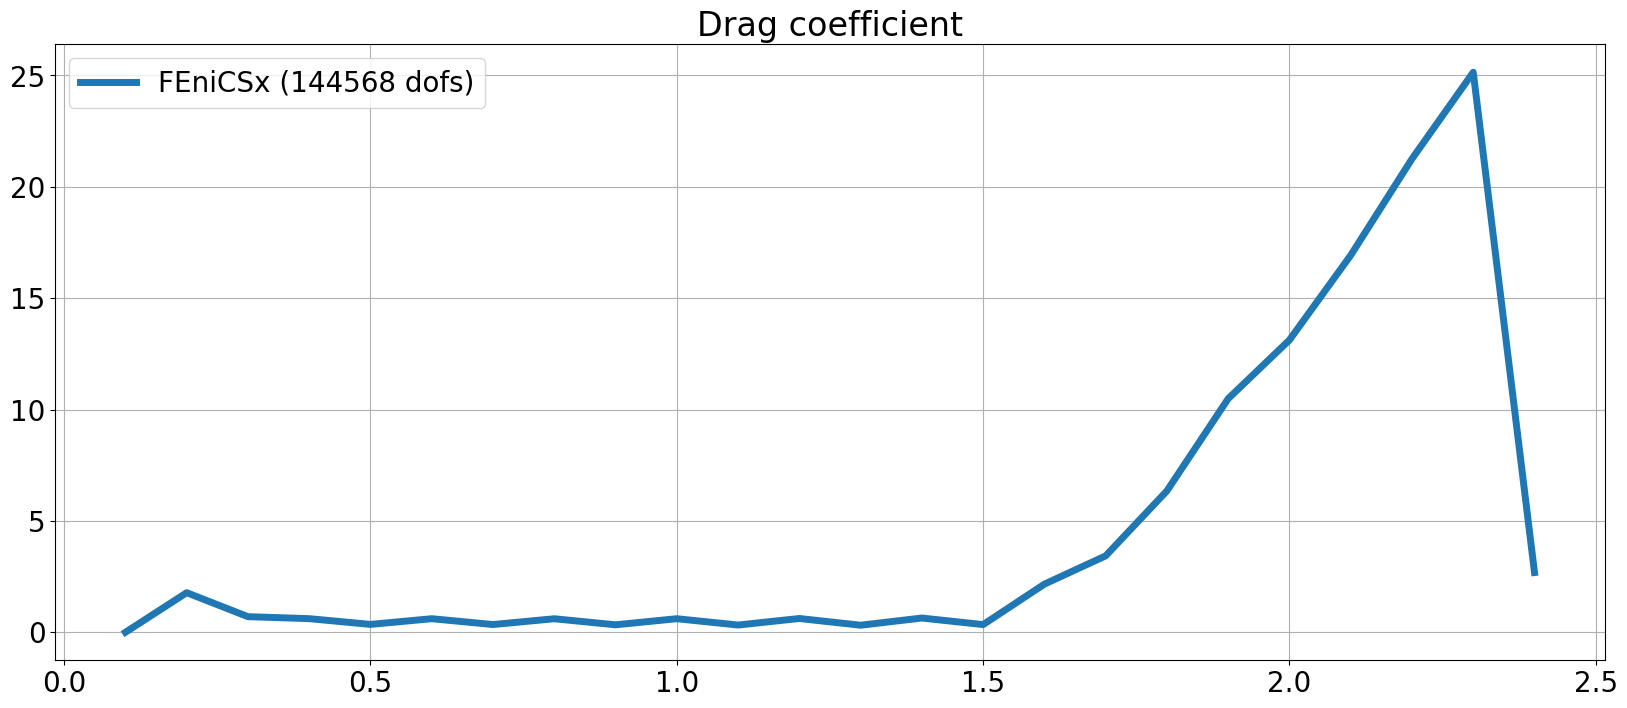

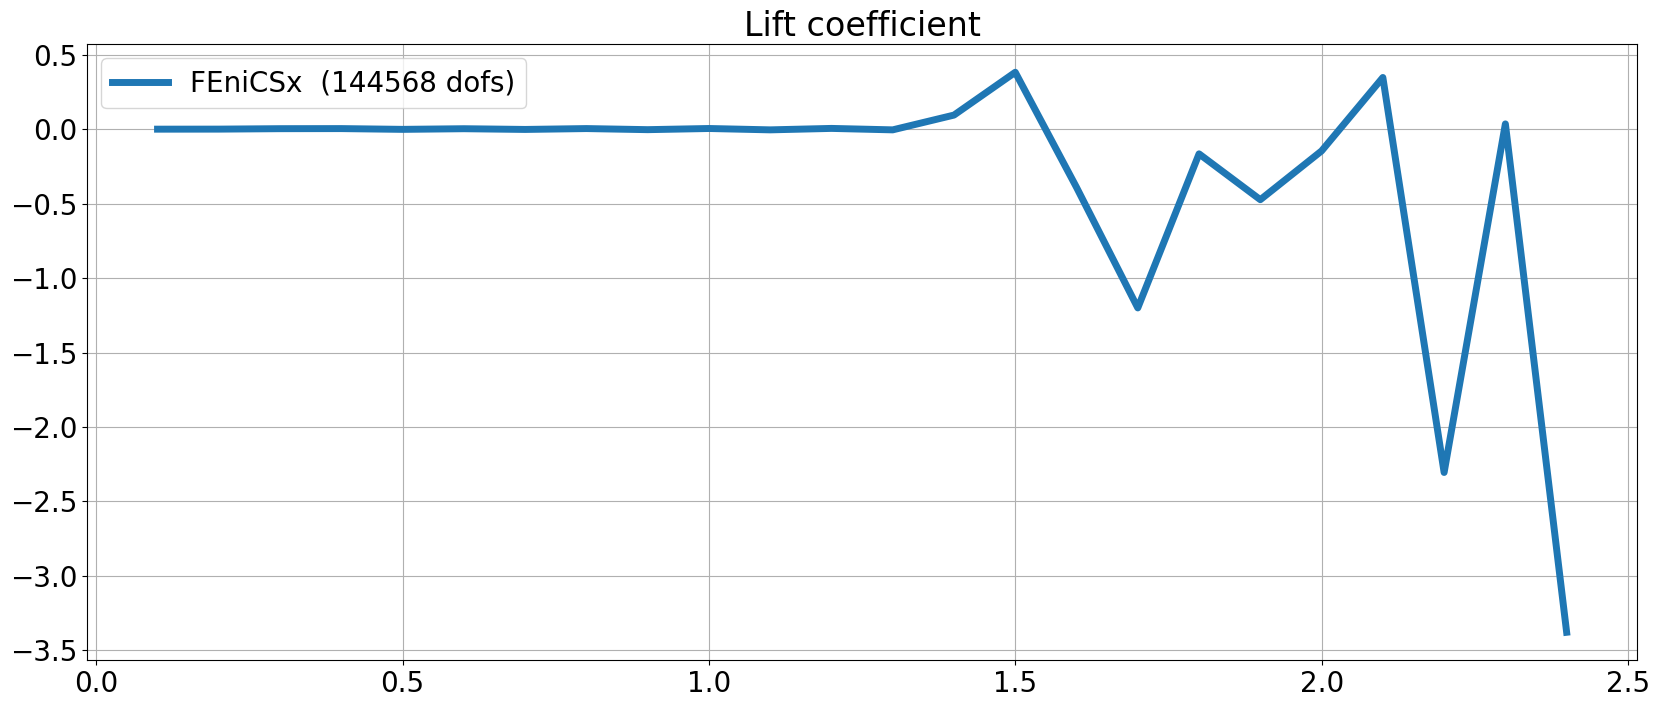

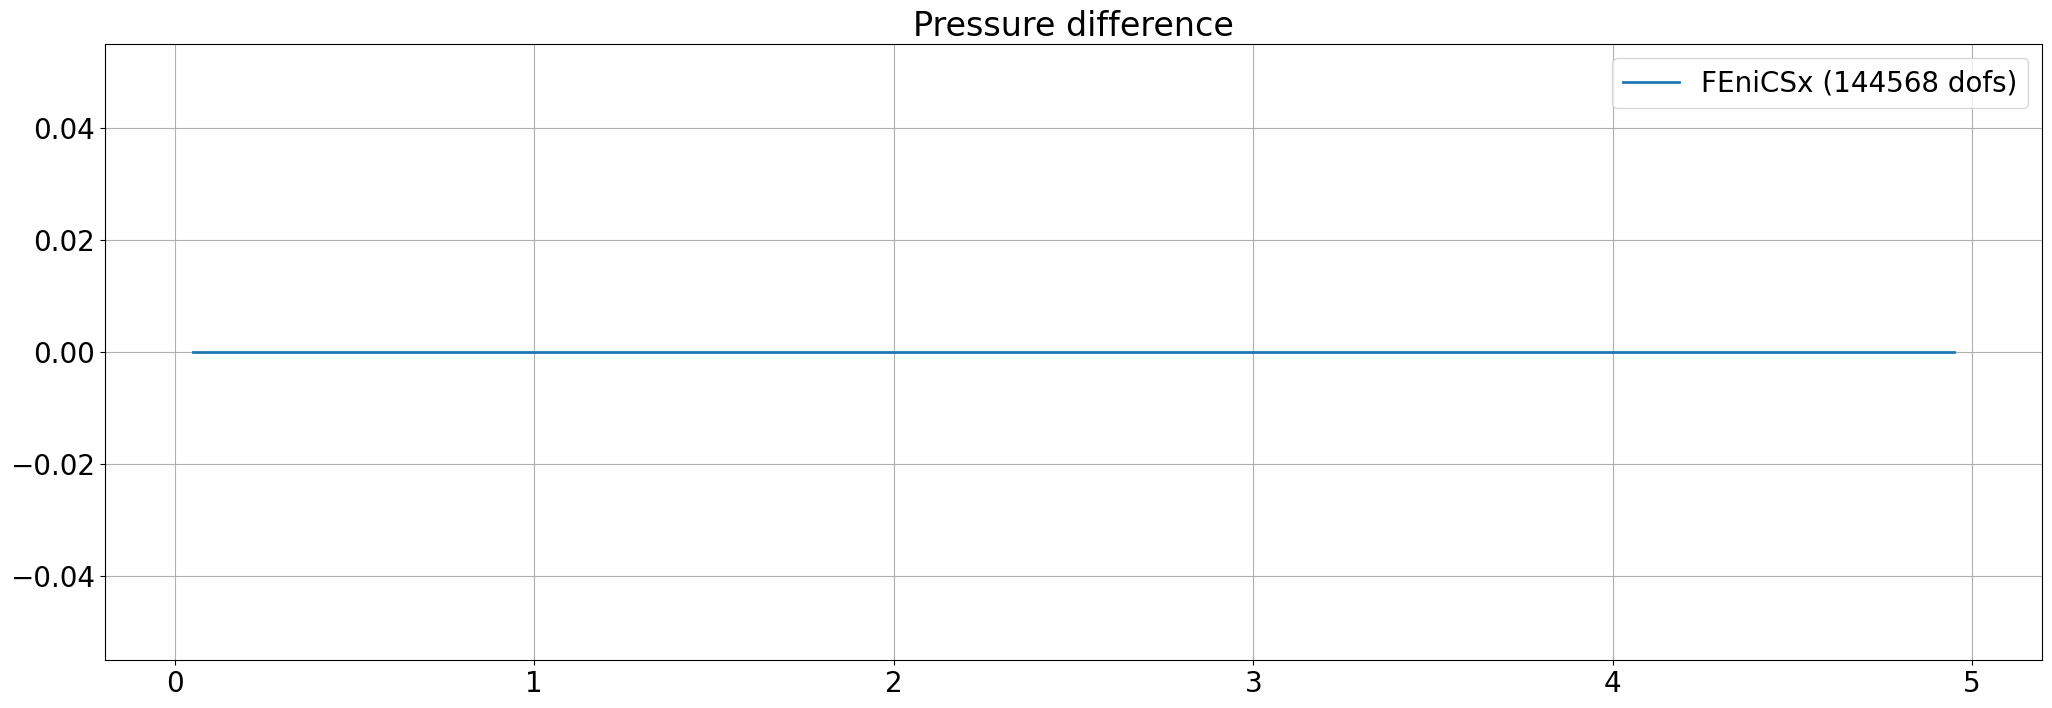

In [17]:
import os
import matplotlib.pyplot as plt
if mesh.comm.rank == 0:
    if not os.path.exists("figures"):
        os.mkdir("figures")
    num_velocity_dofs = V.dofmap.index_map_bs * V.dofmap.index_map.size_global
    num_pressure_dofs = Q.dofmap.index_map_bs * V.dofmap.index_map.size_global


    # fig = plt.figure(figsize=(20, 8))
    # l1 = plt.plot(
    #     t_u,
    #     C_D,
    #     label=r"FEniCSx  ({0:d} dofs)".format(num_velocity_dofs + num_pressure_dofs),
    #     linewidth=2,
    # )

    plt.rcParams.update({'font.size': 20}) # Increased from default (e.g., to 20)

    
    fig = plt.figure(figsize=(20, 8))
    l1 = plt.plot(
        t_u[0:24],
        C_D[0:24],
        label=r"FEniCSx ({0:d} dofs)".format(num_velocity_dofs + num_pressure_dofs),
        linewidth=5, # Increased from 2 to 5 for a thicker line
    )


    plt.title("Drag coefficient")
    plt.grid()
    plt.legend()
    plt.savefig("figures/drag_comparison_3D_wing.png")
    plt.rcParams.update({'font.size': 20})
    fig = plt.figure(figsize=(20, 8))
    l1 = plt.plot(
        t_u[0:24],
        C_L[0:24],
        label=r"FEniCSx  ({0:d} dofs)".format(num_velocity_dofs + num_pressure_dofs),
        linewidth=5,
    )

    plt.title("Lift coefficient")
    plt.grid()
    plt.legend()
    plt.savefig("figures/lift_comparison_3D_wing.png")

    fig = plt.figure(figsize=(25, 8))
    l1 = plt.plot(
        t_p,
        p_diff,
        label=r"FEniCSx ({0:d} dofs)".format(num_velocity_dofs + num_pressure_dofs),
        linewidth=2,
    )

    plt.title("Pressure difference")
    plt.grid()
    plt.legend()
    plt.savefig("figures/pressure_comparison_3D_wing.png")

In [15]:
import numpy as np
import pyvista as pv

# ----------------------------
# User controls
# ----------------------------
PVD_FILE = "results/velocity.pvd"
TIME_INDEX = 30            # <-- choose time step index here
SLICE_NORMAL = (0, 0, 1)   # (0,0,1)=XY, (0,1,0)=XZ, (1,0,0)=YZ
COLORMAP = "viridis"

# ----------------------------
# Load time-series
# ----------------------------
reader = pv.get_reader(PVD_FILE)
time_values = reader.time_values

if len(time_values) == 0:
    raise RuntimeError("No time steps found in the PVD file.")

if TIME_INDEX >= len(time_values):
    raise ValueError(f"TIME_INDEX must be < {len(time_values)}")

# Activate selected time step
reader.set_active_time_value(time_values[TIME_INDEX])
data = reader.read()

# Handle MultiBlock output (common with DOLFINx)
if isinstance(data, pv.MultiBlock):
    grid = data[0]
else:
    grid = data

# ----------------------------
# Compute velocity magnitude |u|
# ----------------------------
velocity = grid.point_data["u"]
speed = np.linalg.norm(velocity, axis=1)
grid.point_data["|u|"] = speed

# ----------------------------
# Slice domain
# ----------------------------
slice_xy = grid.slice(normal=SLICE_NORMAL)

# ----------------------------
# Plot
# ----------------------------
p = pv.Plotter()
p.add_mesh(slice_xy, scalars="|u|", cmap=COLORMAP)
p.add_scalar_bar("|u|")
p.add_text(f"Time index: {TIME_INDEX}\nTime value: {time_values[TIME_INDEX]:.4f}")
p.show()


2026-02-04 15:50:39.740 (   1.826s) [    7C4243188600]     vtkOpenGLState.cxx:1787  WARN| Hardware does not support the number of textures defined.
2026-02-04 15:50:39.741 (   1.827s) [    7C4243188600]     vtkOpenGLState.cxx:1787  WARN| Hardware does not support the number of textures defined.
2026-02-04 15:50:39.741 (   1.827s) [    7C4243188600]     vtkOpenGLState.cxx:1787  WARN| Hardware does not support the number of textures defined.
2026-02-04 15:50:39.741 (   1.827s) [    7C4243188600]     vtkOpenGLState.cxx:1787  WARN| Hardware does not support the number of textures defined.
2026-02-04 15:50:39.741 (   1.827s) [    7C4243188600]     vtkOpenGLState.cxx:1787  WARN| Hardware does not support the number of textures defined.
2026-02-04 15:50:39.741 (   1.827s) [    7C4243188600]     vtkOpenGLState.cxx:1787  WARN| Hardware does not support the number of textures defined.
2026-02-04 15:50:39.741 (   1.827s) [    7C4243188600]     vtkOpenGLState.cxx:1787  WARN| Hardware does not supp

Widget(value='<iframe src="http://localhost:37329/index.html?ui=P_0x7c419c63d480_0&reconnect=auto" class="pyvi…